# Grain boundary segmentation - Pixelated: Part - 3

In [1]:
from upxo.ggrowth.mcgs import mcgs
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries
import upxo.gbops.mcgb2dops as gbops2d
import upxo.gsdataops.grid_ops as gridOps

input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\gschar\\gschar3.xls'
pxt = mcgs(input_dashboard=input_dashboard)
pxt.simulate()
pxt.detect_grains(library='cc3d', process_individual_states=True)
# pxt.gs[3].lgi = np.asarray(pxt.gs[3].lgi, dtype=np.int32)
pxt.gs[3].char_morph_2d(npixels=True)
pxt.gs[3].find_neigh(include_central_grain=False, print_msg=True, use_numba=False,
                     user_defined_bbox_ex_bounds=False, bbox_ex_bounds=None,
                     update_grain_object=True)

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\gschar\gschar3.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 150.0, 1.0
     ymin, ymax, yinc: 0.0, 150.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 20
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stored
GS temporal slice 16 stored
GS temporal slice 17 stored
GS

# [A] <span style="color:orange">**Pipeline - 1**</span>: Grain boundary operations

In [2]:
lfi_boundaries, segInfo, bseg_props = gbops2d.PL_cell_boundaries(lfi=pxt.gs[3].lgi,
                                 nfeatures=pxt.gs[3].n,
                                 neigh_fid=pxt.gs[3].neigh_gid,
                                 connectivity=1,
                                 mode='thick',
                                 background=0,
                                 local_seg_id_nDecPlaces=4,
                                 segIDMask_dtype=np.int32)

Segmentation successfull Number of bsegCoords equals number of nearest neighs for all features.


# [B] <span style="color:orange">**Pipeline - 2**</span>: Boundary Junction point operations - Pixellated

In [3]:
junctionPoints, JPSorted, JPOStats = gbops2d.PL_cellb_junction_points(segInfo['bsegCoords'], 
                                                  segInfo['segidList_gbl'])

## [A.1] <span style="color:orange">Masking</span>: local segment IDs

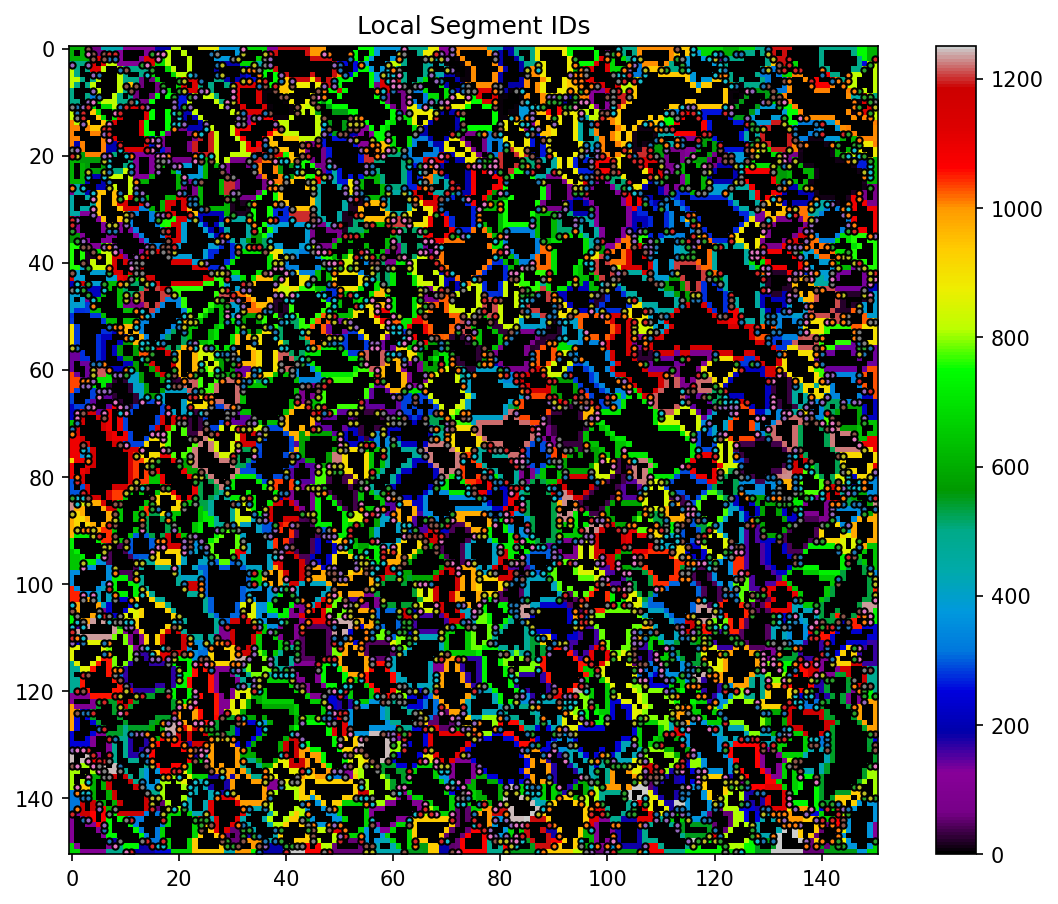

In [13]:
localSegIDMasked_lfi = gridOps.mask_featIDImg_at_coords(lfi_boundaries,
                                                        segInfo['bsegCoords'], 
                                                        segInfo['local_seg_ids'],
                                                        featName='fbseg',
                                                        maskDType=np.int32)
plt.figure(figsize=(10, 7), dpi=150)
plt.imshow(localSegIDMasked_lfi, cmap='nipy_spectral')
plt.title('Local Segment IDs')
plt.colorbar()
for jps in JPSorted['tjp'].values():
    plt.plot(jps[:, 1], jps[:, 0], 'o', markersize=3, markeredgecolor='black',)

## [A.2] <span style="color:orange">Masking</span>: global segment IDs

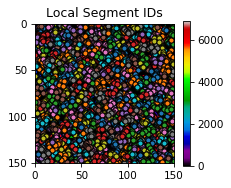

In [14]:
globalSegIDMasked_lfi = gridOps.mask_featIDImg_at_coords(lfi_boundaries,
                                                        segInfo['bsegCoords'], 
                                                        segInfo['global_seg_ids'],
                                                        featName='fbseg',
                                                        maskDType=np.int32)
plt.figure(figsize=(3, 2.5), dpi=75)
plt.imshow(globalSegIDMasked_lfi, cmap='nipy_spectral')
plt.title('Local Segment IDs')
plt.colorbar()
for jps in JPSorted['tjp'].values():
    plt.plot(jps[:, 1], jps[:, 0], 'o', markersize=5, markeredgecolor='black',)

# See boundary segments of the largest grain.

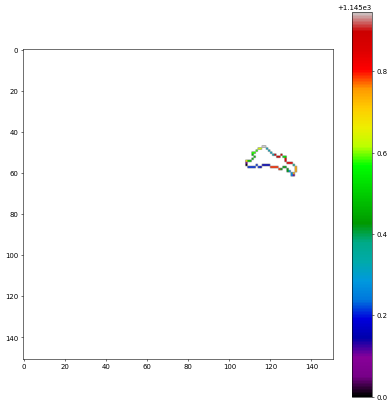

In [15]:
gid = np.argmax(pxt.gs[3].prop.npixels.to_numpy())+1
gbops2d.see_bsegs_gids(localSegIDMasked_lfi, gid)

# Detect the common interface boundaries

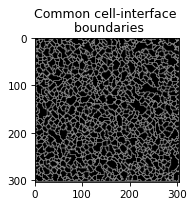

In [16]:
com_int_gbound = gbops2d.find_common_interface_boundaries(lfi=pxt.gs[3].lgi, nfeatures=pxt.gs[3].n)
plt.figure(figsize=(3, 2.5), dpi=75)
plt.imshow(com_int_gbound, cmap='nipy_spectral')
plt.title('Common cell-interface \n boundaries')
plt.show()

### Lets use the proper visualizxation

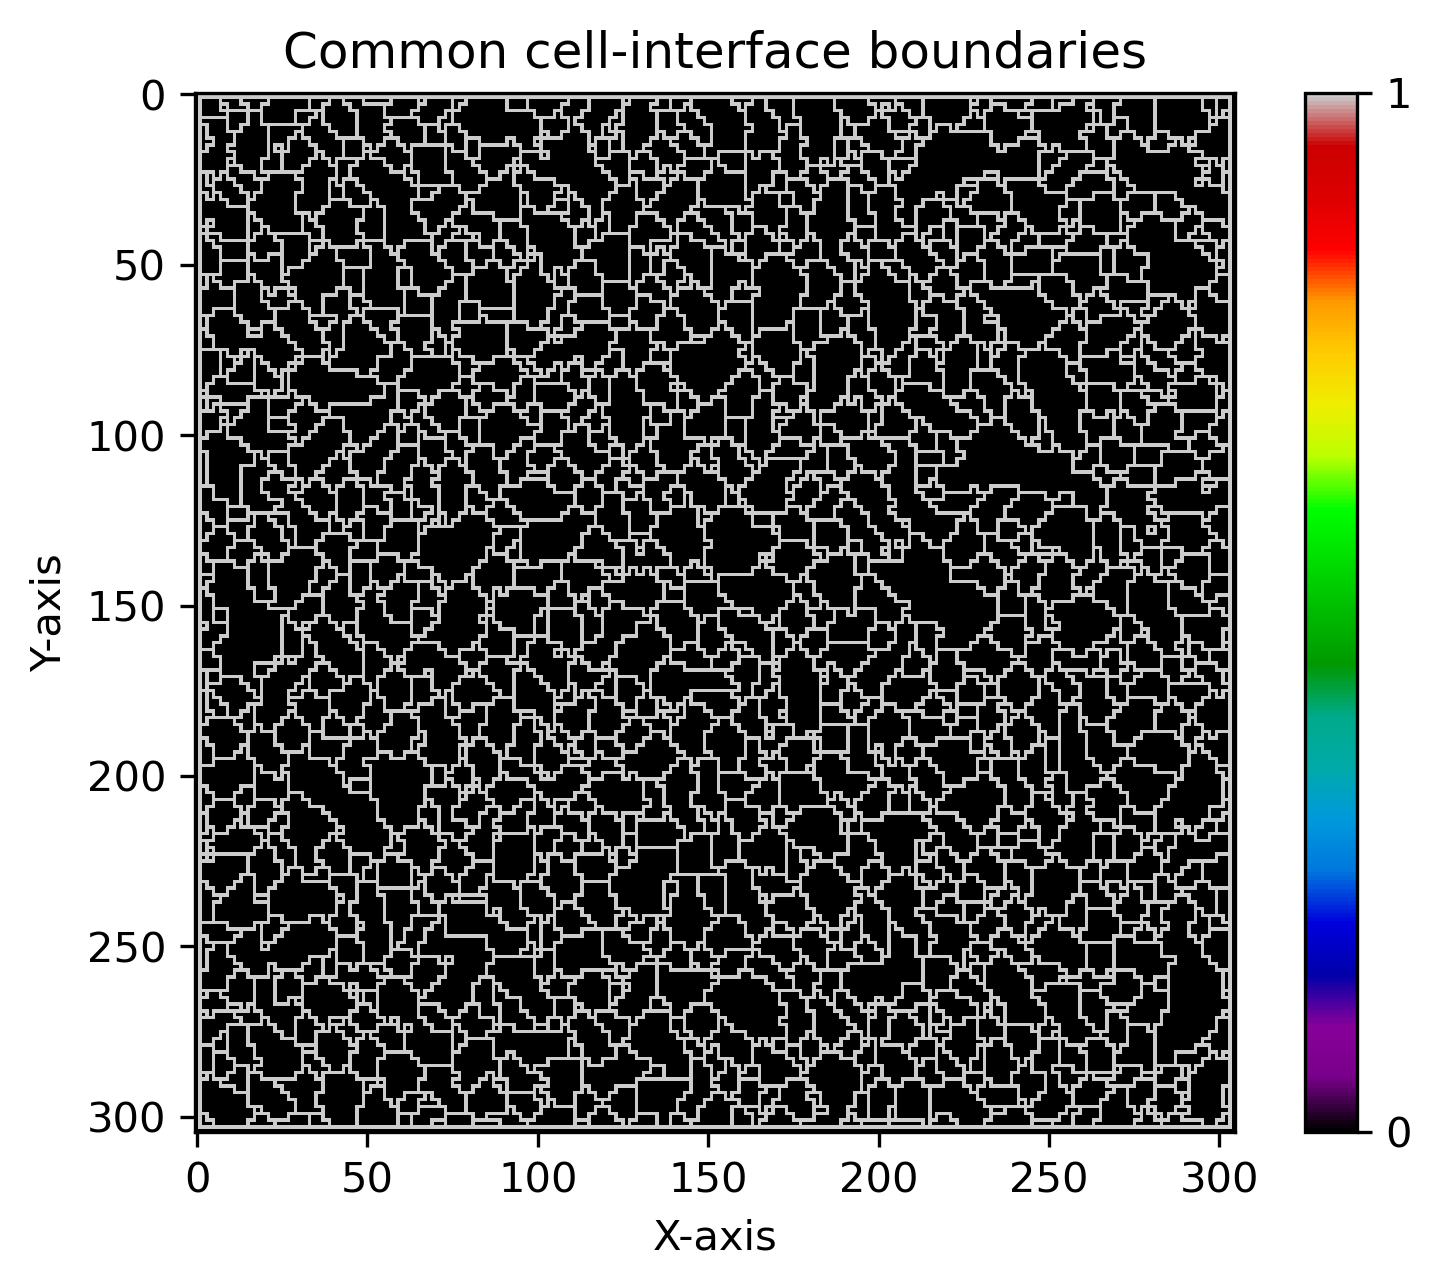

<Axes: title={'center': 'Common cell-interface boundaries'}, xlabel='X-axis', ylabel='Y-axis'>

In [17]:
from upxo.viz import gsviz
gsviz.see_map(com_int_gbound, cmap='nipy_spectral', 
            figsize=(8, 6), dpi=100, vmin=None, vmax=None,
            title='Common cell-interface boundaries', xlabel='X-axis', ylabel='Y-axis',
            cmlabel='', cbar_ticks=[0, 1], preset='publication', ax=None, show=True)

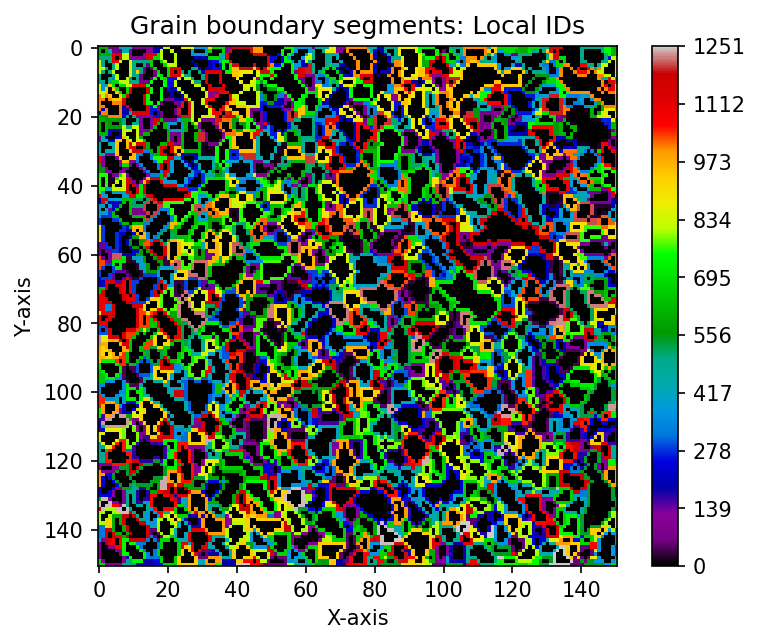

<Axes: title={'center': 'Grain boundary segments: Local IDs'}, xlabel='X-axis', ylabel='Y-axis'>

In [18]:
from upxo.viz import gsviz
gsviz.see_map(localSegIDMasked_lfi, cmap='nipy_spectral', 
            figsize=(8, 6), dpi=150, vmin=None, vmax=None,
            title='Grain boundary segments: Local IDs', xlabel='X-axis', ylabel='Y-axis',
            cmlabel='', cbar_ticks=np.linspace(0, localSegIDMasked_lfi.max(), 10), preset='publication', ax=None, show=True)

In [19]:
pxt.gs[3].g[1]['grain'].bbox_ex

array([[0, 1, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 1, 1, 1, 0],
       [0, 0, 0, 1, 1, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 1, 1, 1, 0],
       [0, 0, 0, 0, 1, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=uint8)